In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle
from specparam import SpectralModel
from specparam import Bands
import neurodsp as ndp
from scipy.stats import zscore

# NeuroDSP scipy and FOOOF modules
from neurodsp import spectral




#  modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from signal_utils import * 
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS

### Set up

In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

#### Step 0: Get loaded data

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'

In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

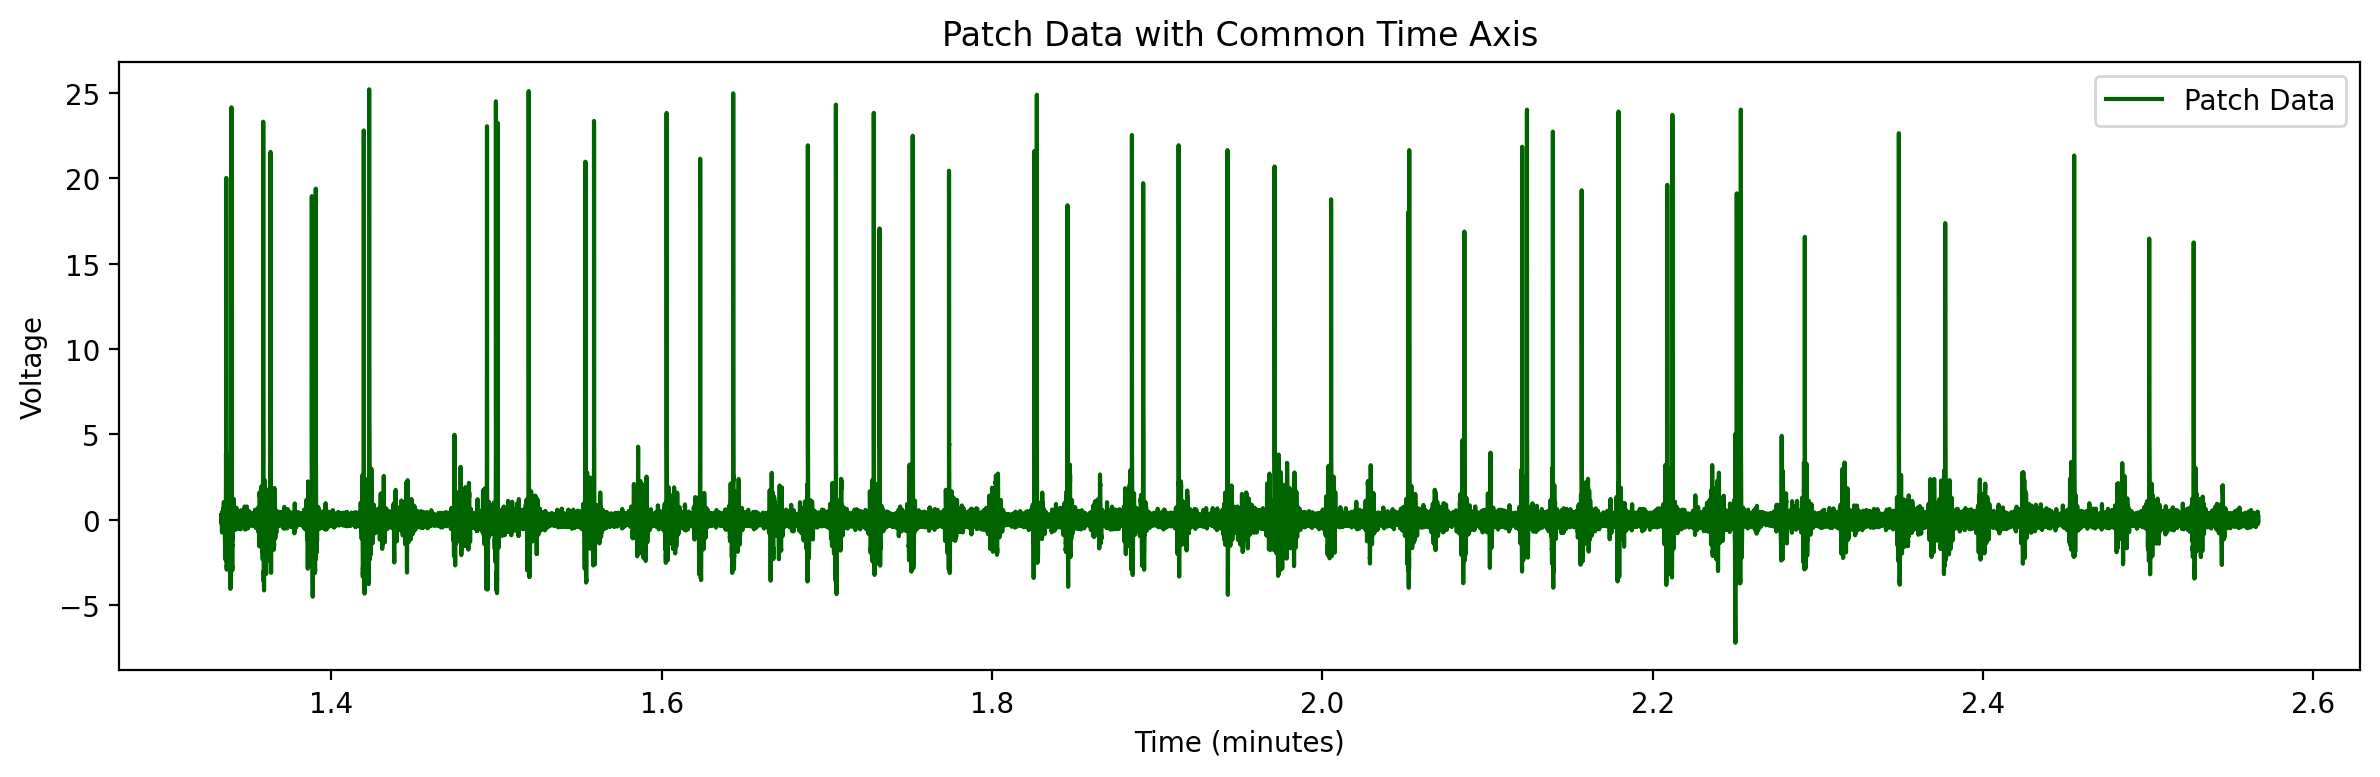

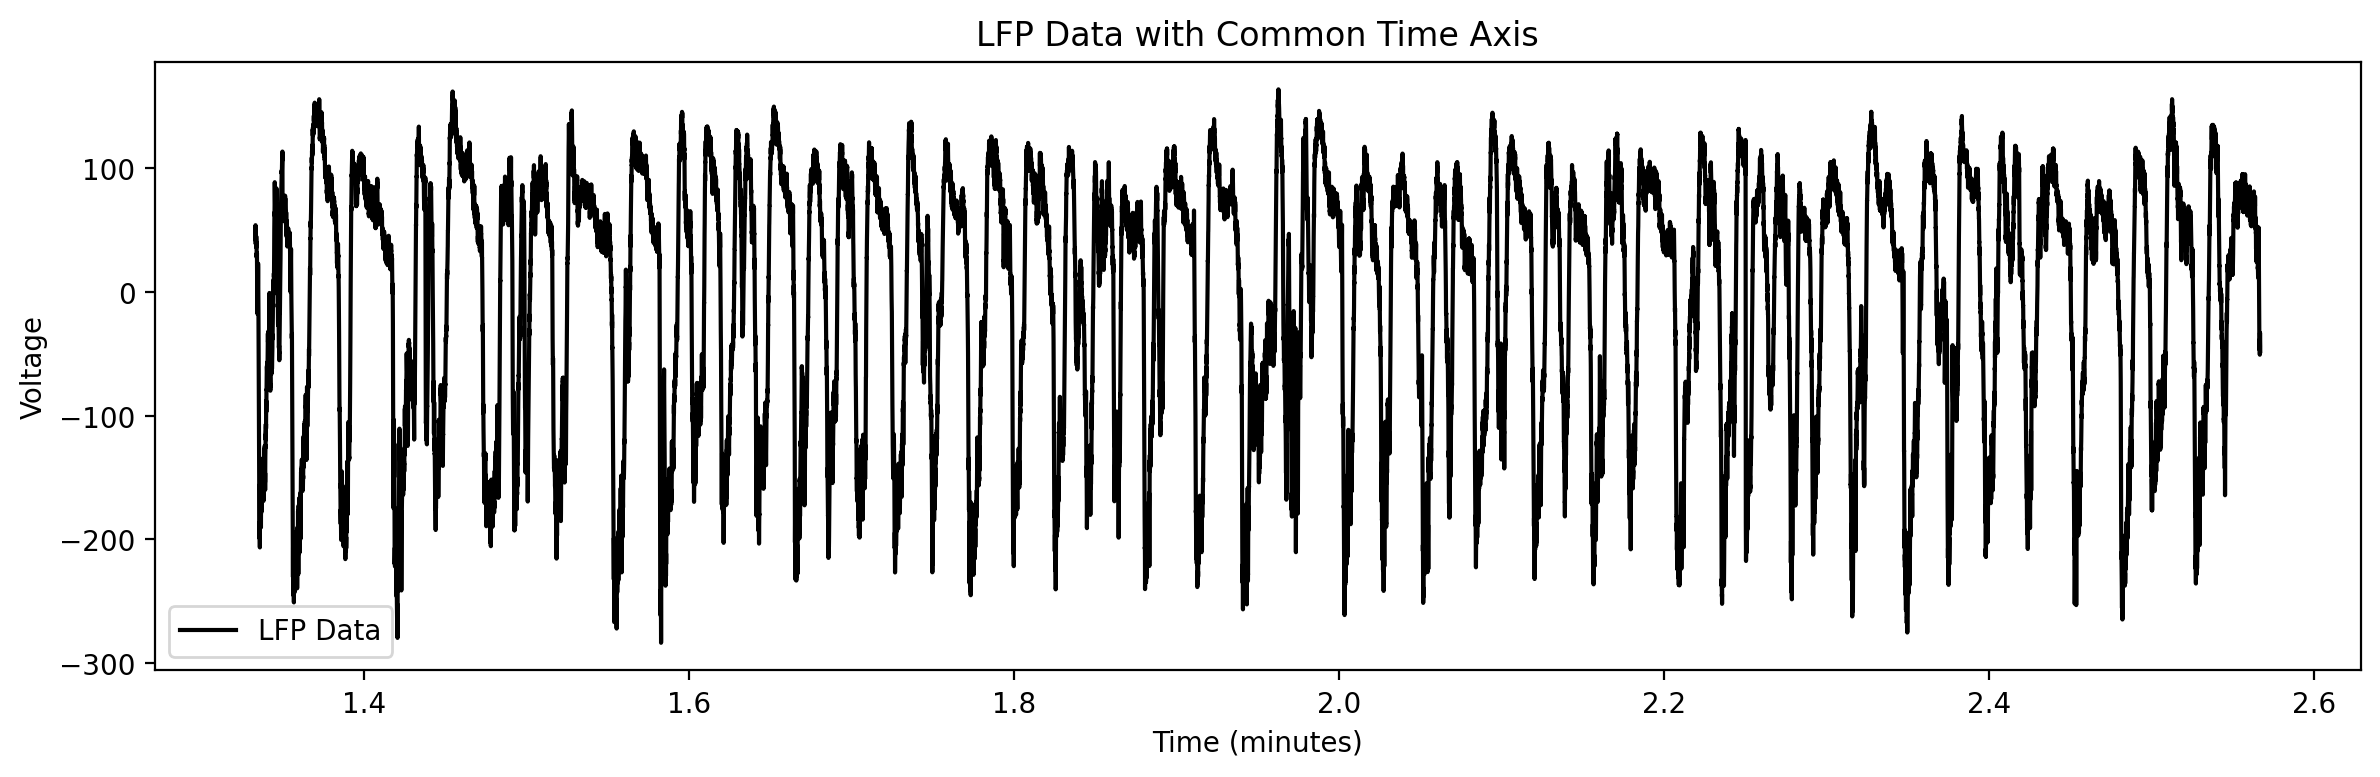

In [6]:
_ =  plot_patch_lfp_aligned(
    patch_times, patch_filt, lfp_times, lfp_filt,
    t_start_ms=80000, t_end_ms=154000
)


## STEP 1: ANALYZE LFP DATA

In [ ]:

# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


### There seem to be some gamma oscillations 

#### Use specpram to find gamma peaks

In [ ]:
fm = SpectralModel(max_n_peaks=1, verbose=False)
fm.fit(fxx, pxx, freq_range=(5,90))
fm.plot()

# A) Long window specparam classification for kilosort

In [ ]:

# SHARED PARAMETERS
lfp_signal = lfp_filt
fs = lfp_fs

# Windowing parameters
window_len_sec = 2
step_size_sec = 1

# Specparam fitting options
fooof_params = {"max_n_peaks": 4, "peak_width_limits": (4, 8), "verbose": False}


In [ ]:
# Define a bands object to organize peak parameters
bands = Bands({'gamma' : [30, 90]})

In [ ]:
# ---- Compute Welch-based model ----
model_welch, freqs_welch, win_times_welch = compute_lfp_windows(
    lfp_signal=lfp_signal,
    fs=fs,
    method="welch",
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params=fooof_params,
    welch_params={"window": "hann", "nperseg": int(fs)}
)



In [ ]:
model_welch.report(peak_org=bands)

In [ ]:
# Get summary df
summary_df_welch = model_welch.to_df(peak_org=bands)

In [ ]:
# Segment windows and blocks
high_windows_welch, low_windows_welch, high_blocks_welch, low_blocks_welch = segment_gamma_epochs(
    summary_df_welch,
    win_times_welch,
    lfp_signal,
    fs,
    window_len_sec=window_len_sec,
    gamma_band_name="gamma",
    visualize=True
)


### Visualize specparam results for low vs high gamma windows 

In [ ]:
plot_param_spectra_high_low(
    model_welch,
    high_windows_welch,     
    low_windows_welch,       
    window_times=win_times_welch,
    title="Welch: Average Parameterized Spectra High vs Low Gamma"
)


### Replicate with multitapers

In [ ]:
# Use multitaper method instead of Welch
model_mt, freqs_mt, win_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method='multitaper',  
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params={"max_n_peaks": 4, "verbose": False},
    multitaper_params={"bandwidth": 4}  
)

In [ ]:
model_mt.report(peak_org=bands)

In [ ]:
# Get summary df
summary_df_mt = model_mt.to_df(peak_org=bands)

In [ ]:
high_windows_mt, low_windows_mt, high_blocks_mt, low_blocks_mt = segment_gamma_epochs(summary_df_mt, win_times_mt, lfp_filt, lfp_fs)

In [ ]:
plot_param_spectra_high_low(
    model_mt,
    high_windows_mt,      
    low_windows_mt,       
    window_times=win_times_mt,
    title="MT: Average Parameterized Spectra High vs Low Gamma"
)


### Compare blocks assigned by both methods 

In [ ]:
# Compute overlap between Welch and Multitaper high gamma blocks
_, overlap_high_segments = compute_block_overlap(high_blocks_welch, high_blocks_mt)[:2]

# Compute overlap between Welch and Multitaper low gamma blocks
_, overlap_low_segments = compute_block_overlap(low_blocks_welch, low_blocks_mt)[:2]


In [ ]:
compare_and_plot_gamma_blocks(lfp_signal, fs, high_blocks_welch, low_blocks_welch, high_blocks_mt, low_blocks_mt)


# B) Save high and low blocks as bin files for kilosort 

In [ ]:

def save_lfp_blocks_to_bin(lfp_signal, fs, overlap_high, overlap_low, output_dir):
    """
    Save LFP segments for overlapping high and low gamma blocks as binary (.bin) files.

    Args:
        lfp_signal : 1D numpy array of the LFP signal
        fs : sampling frequency (Hz)
        overlap_high : list of (start_sec, end_sec) tuples for high gamma overlap segments
        overlap_low : list of (start_sec, end_sec) tuples for low gamma overlap segments
        output_dir : full path to the directory where .bin files will be saved
    """
    # Create the directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # --- High Gamma Blocks ---
    for i, (start_sec, end_sec) in enumerate(overlap_high):
        start_idx = int(start_sec * fs)
        end_idx = int(end_sec * fs)
        segment = lfp_signal[start_idx:end_idx].astype('float32')
        file_path = os.path.join(output_dir, f"high_block_{i}.bin")
        segment.tofile(file_path)

    # --- Low Gamma Blocks ---
    for i, (start_sec, end_sec) in enumerate(overlap_low):
        start_idx = int(start_sec * fs)
        end_idx = int(end_sec * fs)
        segment = lfp_signal[start_idx:end_idx].astype('float32')
        file_path = os.path.join(output_dir, f"low_block_{i}.bin")
        segment.tofile(file_path)

    print(f"✅ Saved {len(overlap_high)} high gamma blocks and {len(overlap_low)} low gamma blocks in:\n{output_dir}")


In [ ]:
save_bin_path = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_lfp_bins_c42"


save_lfp_blocks_to_bin(
    lfp_signal=lfp_signal,
    fs=fs,
    overlap_high=overlap_high_segments,
    overlap_low=overlap_low_segments,
    output_dir=save_bin_path
)

# Step 2: Analyze patch spikes from high vs low blocks 

In [ ]:
#parameterize all spikes
spk_thresh = 10
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [ ]:
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)